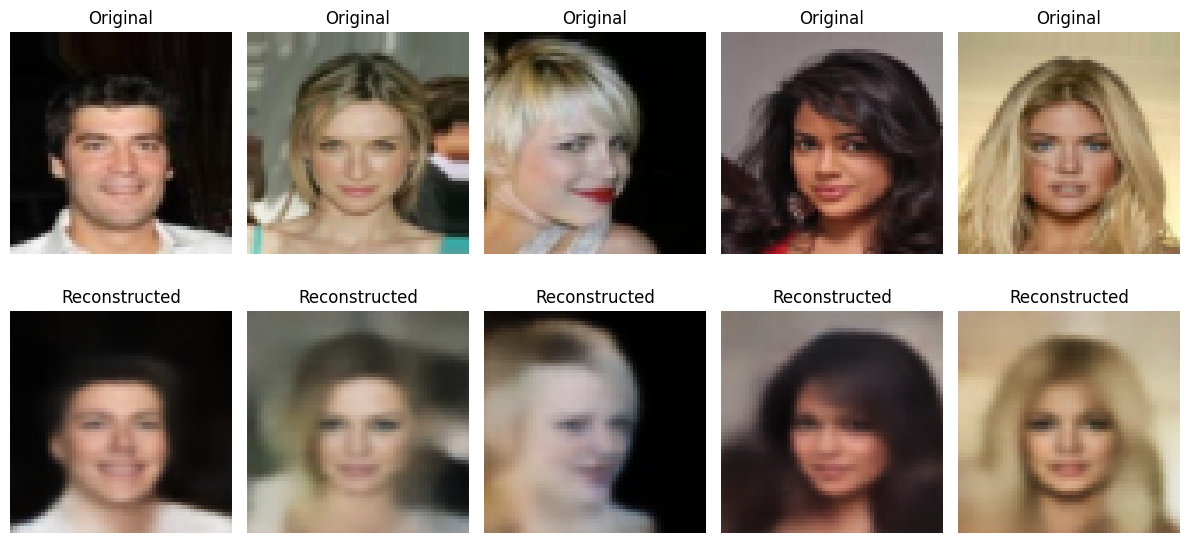

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Model ko evaluation mode mein daala
vae_model.eval()

# 2. Dataloader se ek batch (64 images) uthaya
with torch.no_grad():
    images, _ = next(iter(train_dataloader))
    images = images.to(device)

    # Model se reconstructed images nikali
    reconstructed_res, _, _ = vae_model(images)

# 3. CPU par wapas laaye aur numpy mein badla plotting ke liye
images = images.cpu().numpy()
reconstructed_res = reconstructed_res.cpu().numpy()

# 4. Pehli 5 images ko sath-sath plot karke dekhte hain
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(5):
    # Top Row: Original Images
    orig_img = np.transpose(images[i], (1, 2, 0))
    axes[0, i].imshow(orig_img)
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    # Bottom Row: Reconstructed Images (Jo model ne banayi)
    recon_img = np.transpose(reconstructed_res[i], (1, 2, 0))
    axes[1, i].imshow(recon_img)
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

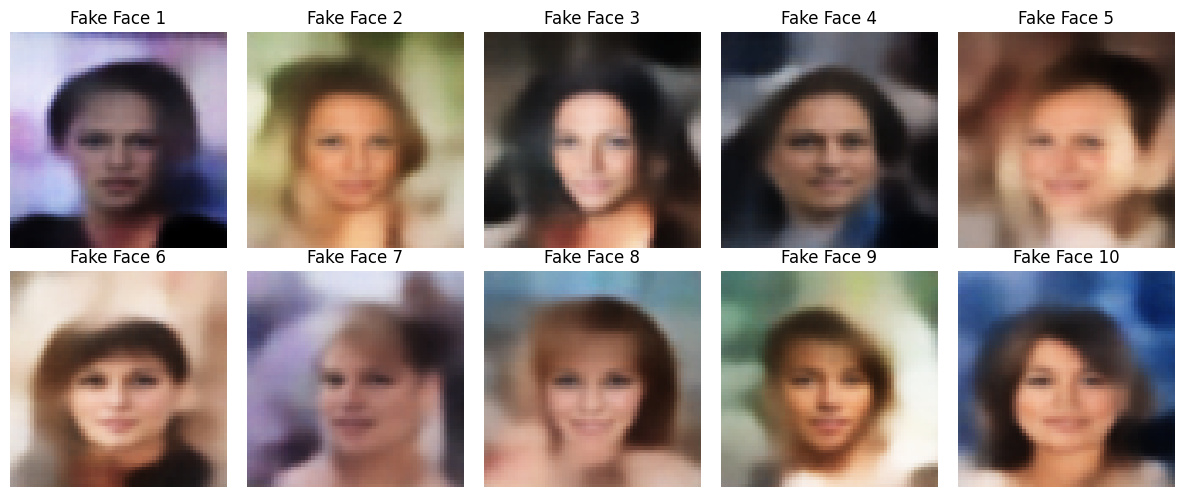

In [ ]:
# 1. Humne khud se 10 random vectors generate kiye (har vector ka size 128)
# Yeh numbers standard normal distribution (Mean=0, Std=1) se aayenge
random_z = torch.randn(10, 128).to(device)

# 2. Direct Decoder se pass karwaya (Encoder ki koi zaroorat nahi)
with torch.no_grad():
    generated_images = vae_model.fc_init(random_z)
    generated_images = vae_model.relu(generated_images)
    generated_images = generated_images.view(-1, 128, 8, 8)

    generated_images = vae_model.relu(vae_model.m1(generated_images))
    generated_images = vae_model.relu(vae_model.m2(generated_images))
    generated_images = vae_model.sigmoid(vae_model.m3(generated_images))

# 3. Ab in 10 ekdum brand new fakes chehron ko plot karte hain
generated_images = generated_images.cpu().numpy()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    row = i // 5
    col = i % 5
    fake_img = np.transpose(generated_images[i], (1, 2, 0))
    axes[row, col].imshow(fake_img)
    axes[row, col].set_title(f"Fake Face {i+1}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

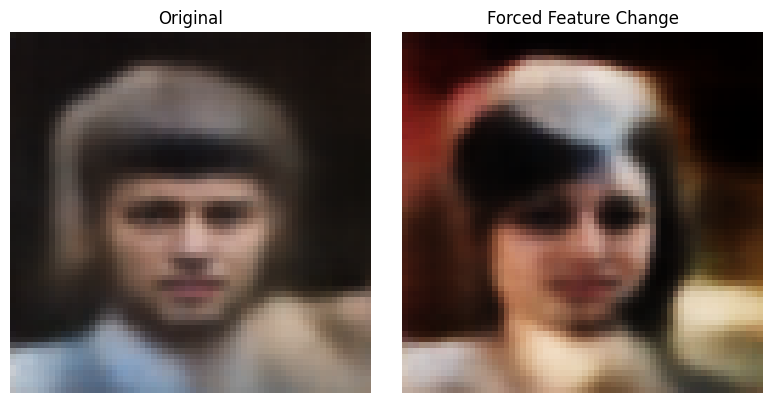

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

vae_model.eval()

# 1. Dataloader se ek batch uthayein
images, _ = next(iter(train_dataloader))
images = images.to(device)

# 2. Pehle saari images ke latent vectors (mu) nikal lete hain
with torch.no_grad():
    out = vae_model.relu(vae_model.conv1(images))
    out = vae_model.relu(vae_model.conv2(out))
    out = vae_model.relu(vae_model.conv3(out))
    flat_x = vae_model.flatten(out)
    all_mu = vae_model.fc_mu(flat_x) # [64, 128]

with torch.no_grad():
    # Base face ka vector uthaya
    base_z = all_mu[0:1].clone()

    # 128 dimensions mein se shuruat ke dimensions ko push karenge
    custom_direction = torch.zeros(1, 128).to(device)
    custom_direction[0, 0:15] = 3.5  # Heavy jump for sharp visual changes

    z_original = base_z
    z_modified = base_z + custom_direction

    # Decoder se output nikalte hain
    # Original Image Flow
    dec_orig = vae_model.relu(vae_model.fc_init(z_original))
    dec_orig = dec_orig.view(-1, 128, 8, 8)
    dec_orig = vae_model.relu(vae_model.m1(dec_orig))
    dec_orig = vae_model.relu(vae_model.m2(dec_orig))
    img_orig = vae_model.sigmoid(vae_model.m3(dec_orig)).cpu().numpy()[0]

    # Modified Image Flow (Yahan fix kar diya hai!)
    dec_mod = vae_model.relu(vae_model.fc_init(z_modified))
    dec_mod = dec_mod.view(-1, 128, 8, 8)
    dec_mod = vae_model.relu(vae_model.m1(dec_mod))
    dec_mod = vae_model.relu(vae_model.m2(dec_mod))
    img_mod = vae_model.sigmoid(vae_model.m3(dec_mod)).cpu().numpy()[0]

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(np.transpose(img_orig, (1, 2, 0)))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(np.transpose(img_mod, (1, 2, 0)))
axes[1].set_title("Forced Feature Change")
axes[1].axis('off')

plt.tight_layout()
plt.show()